# Downloading JWST and Euclid data

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
# Replace this with your Dropbox shared link and modify to dl=1 at the end
dropbox_url = "https://www.dropbox.com/scl/fi/ibbxaq0fj9gkodsu0idow/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE[…]Z_00.00.fits?rlkey=i1pnapefx2uj20v7y33lkl3e3&st=egn0es4i&dl=1"
# Stream the FITS file
response = requests.get(dropbox_url)
response.raise_for_status()  # Ensure successful request
# Read FITS file from memory
fits_file = BytesIO(response.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   


In [12]:
folder_url = "https://caltech.box.com/s/3ykklf78uj89nm0wrc3tpwkkakpsmjju?dl=1"
response = requests.get(folder_url)
response.raise_for_status()

## Using Dropbox API

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox

In [2]:
home = "/Users/emily_ramey"
with open(f"{home}/secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip())
dbx

In [9]:
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

In [11]:
def get_shared_folder_metadata(url):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def download_file(file_path, local_path):
    """Download a file from Dropbox to local storage."""
    try:
        metadata, res = dbx.files_download(path=file_path)
        with open(local_path, "wb") as f:
            f.write(res.content)
            print(f"Downloaded: {file_path} -> {local_path}")
    except dropbox.exceptions.ApiError as e:
        print(f"Error downloading {file_path}: {e}")
        # List and download files

files = get_shared_folder_metadata(jwst_url)
files

AttributeError: 'FileMetadata' object has no attribute 'path'

In [15]:
files[0]
# https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0

FileMetadata(name='mosaic_nircam_f115w_COSMOS-Web_60mas_A4_v0_8_sci.fits', id='id:5_vKHfnAevQAAAAAAFlLZg', client_modified=datetime.datetime(2025, 2, 9, 21, 28, 42), server_modified=datetime.datetime(2025, 2, 10, 19, 15, 10), rev='0162dce86f0f02c00000002d79bc271', size=478281600, path_lower=None, path_display=None, parent_shared_folder_id='12207243889', media_info=None, symlink_info=None, sharing_info=FileSharingInfo(read_only=True, parent_shared_folder_id='12207243889', modified_by='dbid:AAAKZdAVm7hdpPL2i9nKMxvNYGOpfkysKHM'), is_downloadable=True, export_info=None, property_groups=None, has_explicit_shared_members=None, content_hash='b99062c4d14a389a3130cab34fcd07426c555c36e6f109dd475ccf7396b2c9d2', file_lock_info=None)

In [19]:
meta, res = dbx.sharing_get_shared_link_file(jwst_url, path='/'+files[0].name)
res

<Response [200]>

In [20]:
fits_file = BytesIO(res.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      73   (9600, 12455)   float32   


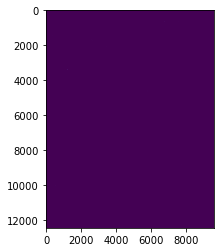

In [21]:
plt.imshow(image_data)

In [13]:
dbx.users_get_current_account()

FullAccount(account_id='dbid:AADh8HWIODgxQU-12PClaS61wrVsJj3VXSI', name=Name(given_name='Emily', surname='Everetts', familiar_name='Emily', display_name='Emily Everetts', abbreviated_name='EE'), email='eaev@caltech.edu', email_verified=True, disabled=False, locale='en', referral_link='https://www.dropbox.com/referrals/AAC1qVwEZhJgvbMnfryWRillDEMWQAtQ2Lg?src=app9-6870097', is_paired=False, account_type=AccountType('basic', None), root_info=UserRootInfo(root_namespace_id='12205527521', home_namespace_id='12205527521'), profile_photo_url=None, country='US', team=None, team_member_id=None)